In [ ]:
import pandas as pd

archivo = 'paraguay_eliminatorias.xlsx'

fixture     = pd.read_excel(archivo, sheet_name='Fixture')
shooting    = pd.read_excel(archivo, sheet_name='Shooting')
goalkeeping = pd.read_excel(archivo, sheet_name='Goalkeeping')
misc        = pd.read_excel(archivo, sheet_name='Miscellaneous')

print("=== FIXTURE ===")
print(fixture.columns.tolist())
print(f"Filas: {len(fixture)}\n")

print("=== SHOOTING ===")
print(shooting.columns.tolist())
print(f"Filas: {len(shooting)}\n")

print("=== GOALKEEPING ===")
print(goalkeeping.columns.tolist())
print(f"Filas: {len(goalkeeping)}\n")

print("=== MISCELLANEOUS ===")
print(misc.columns.tolist())
print(f"Filas: {len(misc)}\n")

=== FIXTURE ===
['Date', 'Time', 'Round', 'Day', 'Venue', 'Result', 'GF', 'GA', 'Opponent', 'Poss', 'Attendance', 'Captain', 'Formation', 'Opp Formation', 'Referee']
Filas: 18

=== SHOOTING ===
['For Paraguay', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Standard', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16']
Filas: 20

=== GOALKEEPING ===
['For Paraguay', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Performance', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Penalty Kicks', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17']
Filas: 20

=== MISCELLANEOUS ===
['For Paraguay', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Performance', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 1

In [3]:
fixture     = pd.read_excel(archivo, sheet_name='Fixture')
shooting    = pd.read_excel(archivo, sheet_name='Shooting', header=1)
goalkeeping = pd.read_excel(archivo, sheet_name='Goalkeeping', header=1)
misc        = pd.read_excel(archivo, sheet_name='Miscellaneous', header=1)

# Limpiar filas vacías o de resumen al final
shooting    = shooting.dropna(subset=['Date'])
goalkeeping = goalkeeping.dropna(subset=['Date'])
misc        = misc.dropna(subset=['Date'])

print("=== SHOOTING ===")
print(shooting.columns.tolist())
print(shooting.head(3))
print("\n=== GOALKEEPING ===")
print(goalkeeping.columns.tolist())
print("\n=== MISCELLANEOUS ===")
print(misc.columns.tolist())

=== SHOOTING ===
['Date', 'Time', 'Round', 'Day', 'Venue', 'Result', 'GF', 'GA', 'Opponent', 'Gls', 'Sh', 'SoT', 'SoT%', 'G/Sh', 'G/SoT', 'PK', 'PKatt']
        Date           Time                    Round  Day Venue Result  GF  \
0 2023-09-07  18:30 (19:30)  World Cup qualification  Thu  Home      D   0   
1 2023-09-12  18:00 (19:00)  World Cup qualification  Tue  Away      L   0   
2 2023-10-12       20:00:00  World Cup qualification  Thu  Away      L   0   

   GA      Opponent  Gls  Sh  SoT  SoT%  G/Sh  G/SoT  PK  PKatt  
0   0       pe Peru    0  19    6  31.6   0.0    0.0   0      0  
1   1  ve Venezuela    0  18    5  27.8   0.0    0.0   0      0  
2   1  ar Argentina    0   4    1  25.0   0.0    0.0   0      0  

=== GOALKEEPING ===
['Date', 'Time', 'Round', 'Day', 'Venue', 'Result', 'GF', 'GA', 'Opponent', 'SoTA', 'GA.1', 'Saves', 'Save%', 'CS', 'PKatt', 'PKA', 'PKsv', 'PKm']

=== MISCELLANEOUS ===
['Date', 'Time', 'Round', 'Day', 'Venue', 'Result', 'GF', 'GA', 'Opponent', 'Cr

In [4]:
# Unir todas las hojas por fecha y rival
df = fixture[['Date', 'Venue', 'Result', 'GF', 'GA', 'Opponent', 'Poss']].copy()

df = df.merge(
    shooting[['Date', 'Sh', 'SoT', 'SoT%', 'G/Sh', 'G/SoT']],
    on='Date', how='left'
)
df = df.merge(
    goalkeeping[['Date', 'Saves', 'Save%', 'CS']],
    on='Date', how='left'
)
df = df.merge(
    misc[['Date', 'CrdY', 'CrdR', 'Fls', 'Int', 'TklW']],
    on='Date', how='left'
)

# Limpiar opponent (FBref agrega código de país al inicio)
df['Opponent'] = df['Opponent'].str.replace(r'^[a-z]{2}\s', '', regex=True)

# Convertir resultado a puntos
def puntos(result):
    if result == 'W': return 3
    if result == 'D': return 1
    return 0

df['Pts'] = df['Result'].apply(puntos)
df['Pts_acum'] = df['Pts'].cumsum()

print(df[['Date', 'Opponent', 'Venue', 'Result', 'GF', 'GA', 'Poss', 'Sh', 'SoT']].to_string())

         Date   Opponent Venue Result  GF  GA  Poss  Sh  SoT
0  2023-09-07       Peru  Home      D   0   0    60  19    6
1  2023-09-12  Venezuela  Away      L   0   1    46  18    5
2  2023-10-12  Argentina  Away      L   0   1    25   4    1
3  2023-10-17    Bolivia  Home      W   1   0    62  13    7
4  2023-11-16      Chile  Away      D   0   0    29  11    3
5  2023-11-21   Colombia  Home      L   0   1    41  13    2
6  2024-09-06    Uruguay  Away      D   0   0    35   8    2
7  2024-09-10     Brazil  Home      W   1   0    29   7    2
8  2024-10-10    Ecuador  Away      D   0   0    23   3    2
9  2024-10-15  Venezuela  Home      W   2   1    61  13    6
10 2024-11-14  Argentina  Home      W   2   1    23   8    2
11 2024-11-19    Bolivia  Away      D   2   2    35  13    4
12 2025-03-20      Chile  Home      W   1   0    36  16    5
13 2025-03-25   Colombia  Away      D   2   2    39  21    6
14 2025-06-05    Uruguay  Home      W   2   0    29  12    5
15 2025-06-10     Brazil

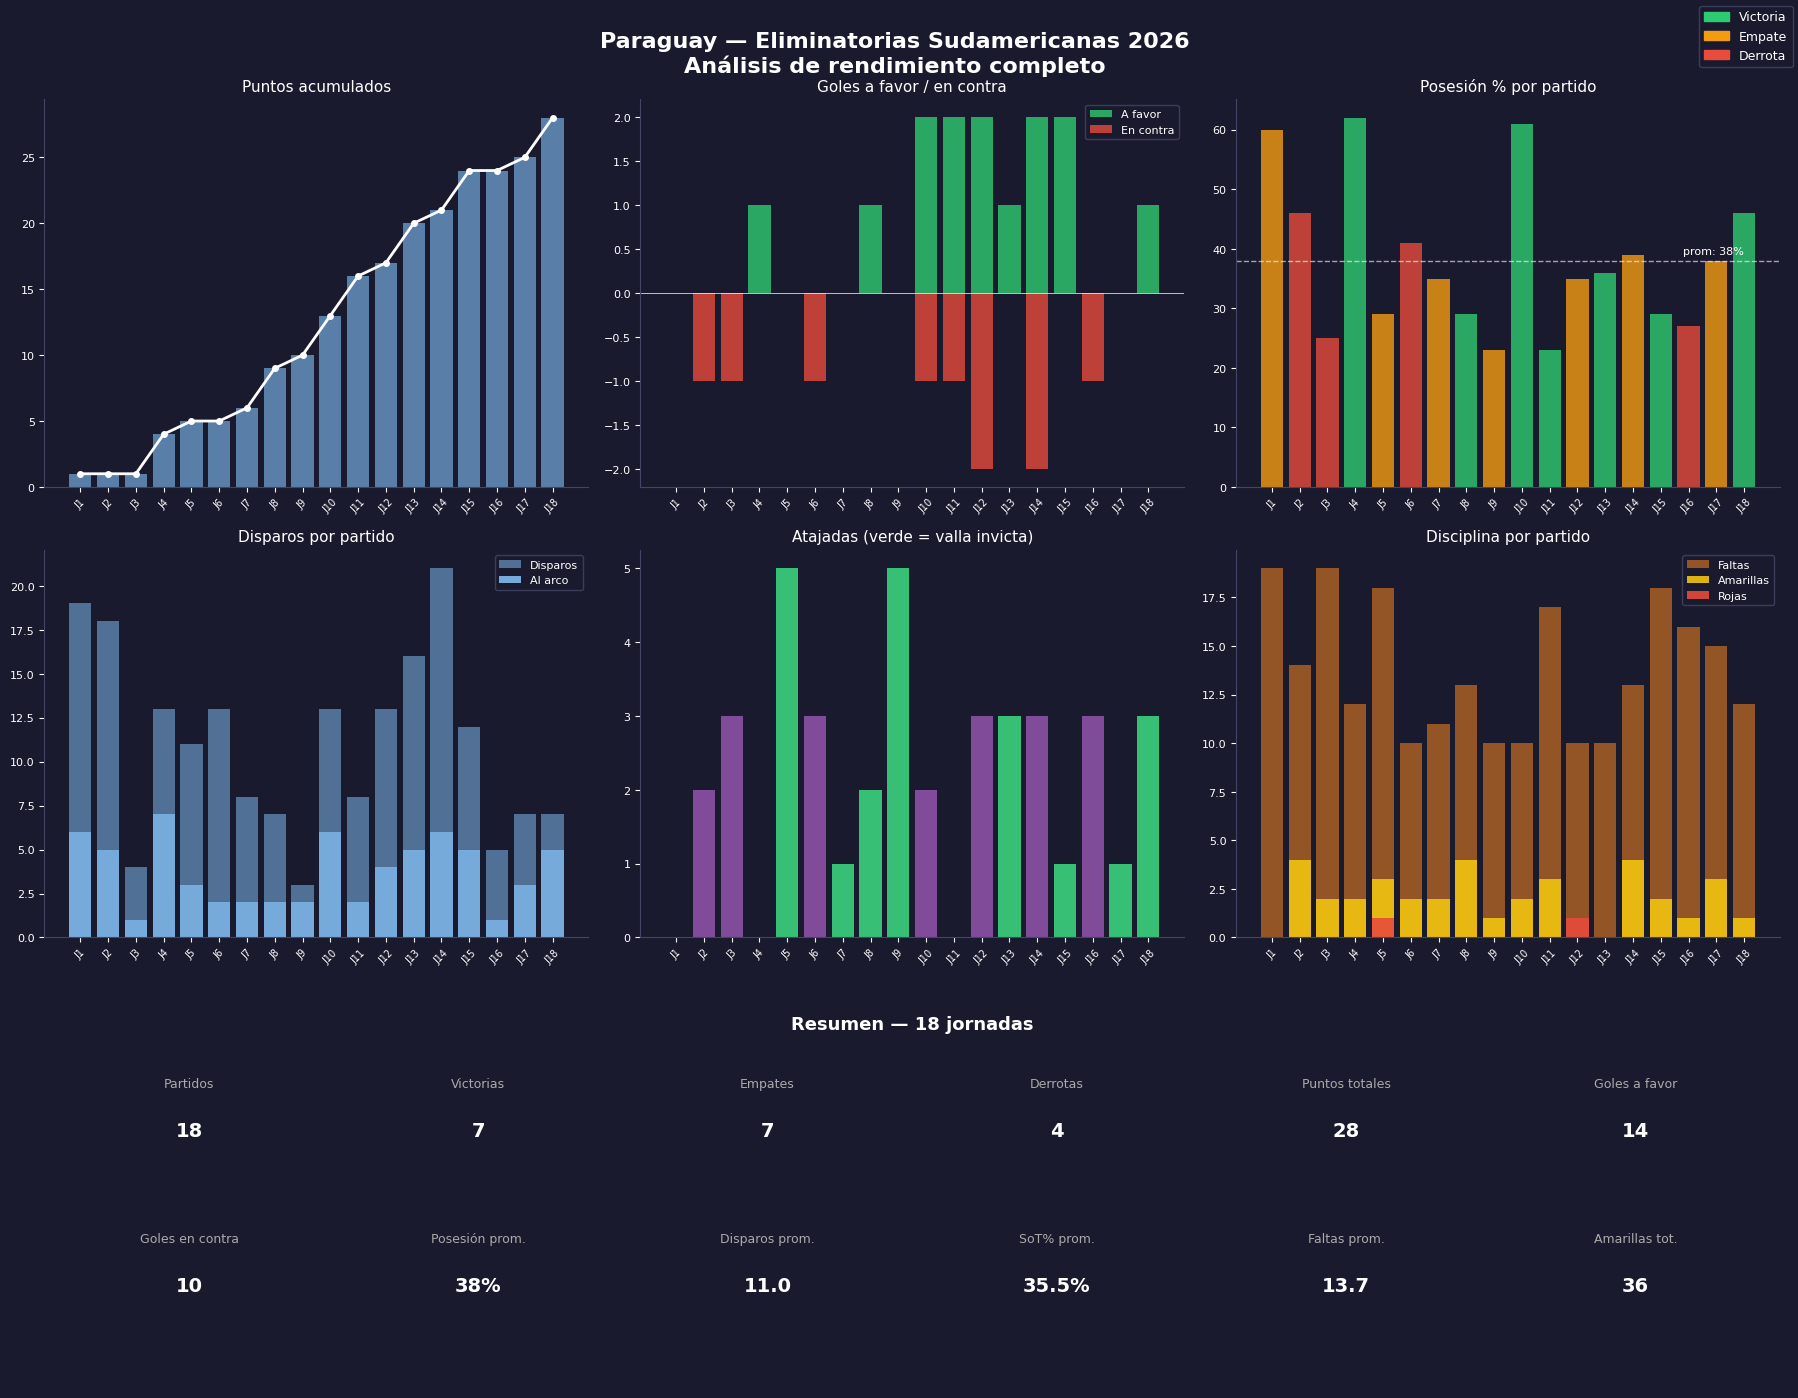

✓ Guardado


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Paraguay — Eliminatorias Sudamericanas 2026\nAnálisis de rendimiento completo',
             color='white', fontsize=16, fontweight='bold', y=0.98)

colores_resultado = {'W': '#2ecc71', 'D': '#f39c12', 'L': '#e74c3c'}

# ── Panel 1: Puntos acumulados ──
ax1 = fig.add_subplot(3, 3, 1)
ax1.set_facecolor('#1a1a2e')
colores_pts = [colores_resultado[r] for r in df['Result']]
ax1.bar(range(len(df)), df['Pts_acum'], color='#75AADB', alpha=0.7)
ax1.plot(range(len(df)), df['Pts_acum'], color='white', linewidth=2, marker='o', markersize=4)
ax1.set_title('Puntos acumulados', color='white', fontsize=11)
ax1.tick_params(colors='white', labelsize=8)
ax1.set_xticks(range(len(df)))
ax1.set_xticklabels([f"J{i+1}" for i in range(len(df))], rotation=45, fontsize=7)
ax1.spines[['top','right']].set_visible(False)
ax1.spines[['left','bottom']].set_color('#444466')
ax1.yaxis.label.set_color('white')

# ── Panel 2: Goles a favor vs en contra ──
ax2 = fig.add_subplot(3, 3, 2)
ax2.set_facecolor('#1a1a2e')
x = range(len(df))
ax2.bar(x, df['GF'], color='#2ecc71', alpha=0.8, label='A favor')
ax2.bar(x, [-g for g in df['GA']], color='#e74c3c', alpha=0.8, label='En contra')
ax2.axhline(0, color='white', linewidth=0.5)
ax2.set_title('Goles a favor / en contra', color='white', fontsize=11)
ax2.tick_params(colors='white', labelsize=8)
ax2.set_xticks(range(len(df)))
ax2.set_xticklabels([f"J{i+1}" for i in range(len(df))], rotation=45, fontsize=7)
ax2.legend(fontsize=8, labelcolor='white', facecolor='#1a1a2e', edgecolor='#444466')
ax2.spines[['top','right']].set_visible(False)
ax2.spines[['left','bottom']].set_color('#444466')

# ── Panel 3: Posesión por partido ──
ax3 = fig.add_subplot(3, 3, 3)
ax3.set_facecolor('#1a1a2e')
colores_pos = [colores_resultado[r] for r in df['Result']]
bars = ax3.bar(range(len(df)), df['Poss'], color=colores_pos, alpha=0.8)
ax3.axhline(df['Poss'].mean(), color='white', linewidth=1, linestyle='--', alpha=0.6)
ax3.text(17, df['Poss'].mean() + 1, f"prom: {df['Poss'].mean():.0f}%", 
         color='white', fontsize=8, ha='right')
ax3.set_title('Posesión % por partido', color='white', fontsize=11)
ax3.tick_params(colors='white', labelsize=8)
ax3.set_xticks(range(len(df)))
ax3.set_xticklabels([f"J{i+1}" for i in range(len(df))], rotation=45, fontsize=7)
ax3.spines[['top','right']].set_visible(False)
ax3.spines[['left','bottom']].set_color('#444466')

# ── Panel 4: Disparos y disparos al arco ──
ax4 = fig.add_subplot(3, 3, 4)
ax4.set_facecolor('#1a1a2e')
ax4.bar(range(len(df)), df['Sh'], color='#75AADB', alpha=0.6, label='Disparos')
ax4.bar(range(len(df)), df['SoT'], color='#75AADB', alpha=1.0, label='Al arco')
ax4.set_title('Disparos por partido', color='white', fontsize=11)
ax4.tick_params(colors='white', labelsize=8)
ax4.set_xticks(range(len(df)))
ax4.set_xticklabels([f"J{i+1}" for i in range(len(df))], rotation=45, fontsize=7)
ax4.legend(fontsize=8, labelcolor='white', facecolor='#1a1a2e', edgecolor='#444466')
ax4.spines[['top','right']].set_visible(False)
ax4.spines[['left','bottom']].set_color('#444466')

# ── Panel 5: Saves y vallas invictas ──
ax5 = fig.add_subplot(3, 3, 5)
ax5.set_facecolor('#1a1a2e')
ax5.bar(range(len(df)), df['Saves'], color='#9b59b6', alpha=0.8)
cs_partidos = df[df['CS'] == 1].index.tolist()
for i in cs_partidos:
    ax5.bar(i, df.loc[i, 'Saves'], color='#2ecc71', alpha=0.9)
ax5.set_title('Atajadas (verde = valla invicta)', color='white', fontsize=11)
ax5.tick_params(colors='white', labelsize=8)
ax5.set_xticks(range(len(df)))
ax5.set_xticklabels([f"J{i+1}" for i in range(len(df))], rotation=45, fontsize=7)
ax5.spines[['top','right']].set_visible(False)
ax5.spines[['left','bottom']].set_color('#444466')

# ── Panel 6: Tarjetas y faltas ──
ax6 = fig.add_subplot(3, 3, 6)
ax6.set_facecolor('#1a1a2e')
ax6.bar(range(len(df)), df['Fls'], color='#e67e22', alpha=0.6, label='Faltas')
ax6.bar(range(len(df)), df['CrdY'], color='#f1c40f', alpha=0.9, label='Amarillas')
ax6.bar(range(len(df)), df['CrdR'], color='#e74c3c', alpha=0.9, label='Rojas')
ax6.set_title('Disciplina por partido', color='white', fontsize=11)
ax6.tick_params(colors='white', labelsize=8)
ax6.set_xticks(range(len(df)))
ax6.set_xticklabels([f"J{i+1}" for i in range(len(df))], rotation=45, fontsize=7)
ax6.legend(fontsize=8, labelcolor='white', facecolor='#1a1a2e', edgecolor='#444466')
ax6.spines[['top','right']].set_visible(False)
ax6.spines[['left','bottom']].set_color('#444466')

# ── Panel 7: Resumen estadístico ──
ax7 = fig.add_subplot(3, 1, 3)
ax7.set_facecolor('#1a1a2e')
ax7.axis('off')

wins   = (df['Result'] == 'W').sum()
draws  = (df['Result'] == 'D').sum()
losses = (df['Result'] == 'L').sum()
pts    = df['Pts_acum'].iloc[-1]

stats_resumen = [
    ('Partidos',        18,                          ''),
    ('Victorias',       wins,                        ''),
    ('Empates',         draws,                       ''),
    ('Derrotas',        losses,                      ''),
    ('Puntos totales',  pts,                         ''),
    ('Goles a favor',   int(df['GF'].sum()),          ''),
    ('Goles en contra', int(df['GA'].sum()),          ''),
    ('Posesión prom.',  f"{df['Poss'].mean():.0f}%", ''),
    ('Disparos prom.',  f"{df['Sh'].mean():.1f}",    ''),
    ('SoT% prom.',      f"{df['SoT%'].mean():.1f}%", ''),
    ('Faltas prom.',    f"{df['Fls'].mean():.1f}",   ''),
    ('Amarillas tot.',  int(df['CrdY'].sum()),        ''),
]

ax7.set_xlim(0, 12)
ax7.set_ylim(0, 2)
ax7.text(6, 1.85, 'Resumen — 18 jornadas', color='white', fontsize=13,
         fontweight='bold', ha='center')

for i, (label, valor, _) in enumerate(stats_resumen):
    x = i % 6
    y = 1.3 if i < 6 else 0.5
    ax7.text(x * 2 + 1, y + 0.25, str(label), color='#aaaaaa', fontsize=9, ha='center')
    ax7.text(x * 2 + 1, y,        str(valor),  color='white',   fontsize=14,
             fontweight='bold', ha='center')

# Leyenda resultados
w_p = mpatches.Patch(color='#2ecc71', label='Victoria')
d_p = mpatches.Patch(color='#f39c12', label='Empate')
l_p = mpatches.Patch(color='#e74c3c', label='Derrota')
fig.legend(handles=[w_p, d_p, l_p], loc='upper right',
           facecolor='#1a1a2e', edgecolor='#444466', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('paraguay_eliminatorias_completo.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("✓ Guardado")